In [114]:
#Kaggleの『AI Learner Tech: EV Prices 2026 (EDA & ML)』
#(https://www.kaggle.com/datasets/ailearner-researchlab/ai-learner-tech-ev-prices-and-specs-2026?select=AI_Learner_EV_Dataset_Pro.csv)
#を使用して欧州で販売されるEV車のコスパTop 10と割高Top 10モデルを予測した。

# =========================
# ① ライブラリ読み込み
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

# =========================
# ② csvデータ読み込み
# =========================
dir_path = '/content/drive/MyDrive/datascience-for-beginner/archive_EV/'
df = pd.read_csv(dir_path + 'AI_Learner_EV_Dataset_Pro.csv')


In [115]:
# =========================
# ③ 外れ値除去（IQR）
# =========================
cols = ["PriceEuro", "TopSpeed_KmH", "Range_Km", "AccelSec"]  #対象の列を指定

def remove_outliers_iqr(df, cols):  #DataFrame（df）と対象列（cols）を受け取る関数を定義
    df_clean = df.copy()  #元データを壊さないためコピーを作成
    for col in cols:
        #四分位数を計算
        Q1 = df_clean[col].quantile(0.25) #Q1（第1四分位数）：小さい順に並べたときの下から25%の位置
        Q3 = df_clean[col].quantile(0.75) #Q3（第3四分位数）：下から75%の位置
        IQR = Q3 - Q1 #IQRを計算
        #外れ値の範囲を決定:この範囲を外れると「外れ値」と認定
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        #外れ値を削除:下限以上、上限以下
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean #最終結果を返す

df = remove_outliers_iqr(df, cols)

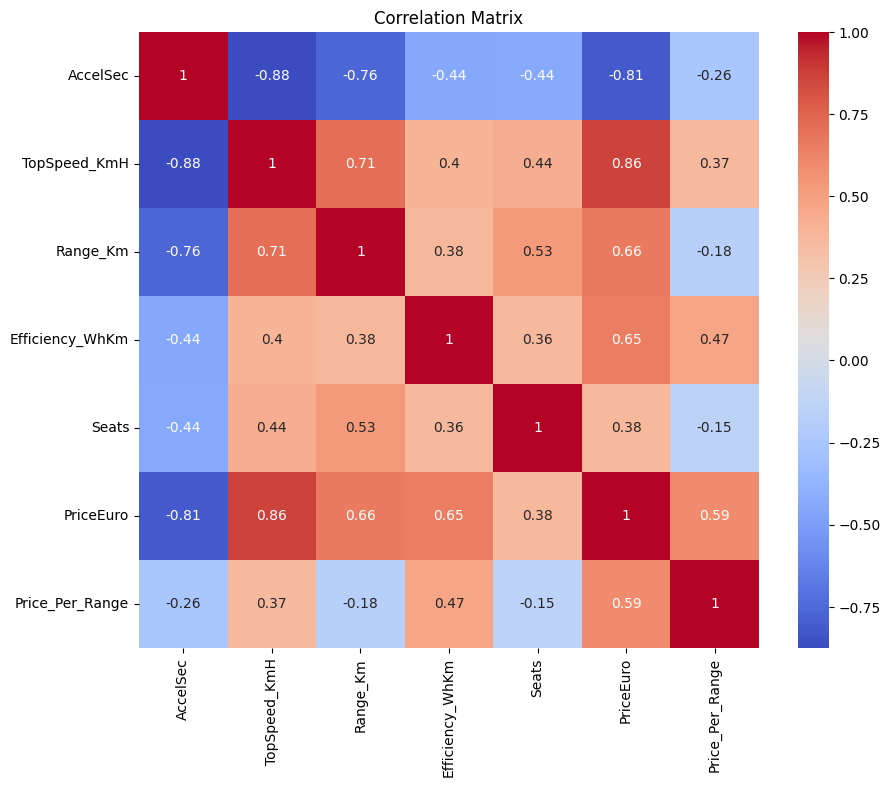

In [116]:
# =========================
# ④ 可視化（相関関係確認）
#Heatmapの表示結果からはAccelSec, TopSpeed_KmHとPriceEuroの相関性が高いように見える
# =========================
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [125]:
# =========================
# ⑤ 特徴量エンジニアリング
# =========================
# ===== データ読み込み =====
#df = pd.read_csv('/content/drive/MyDrive/datascience-for-beginner/archive_EV/AI_Learner_EV_Dataset_Pro.csv')
# ① まず保存 #df["Brand_original"] = df["Brand"]
# ② 特徴量作成
df["Efficiency_Score"] = df["Range_Km"] / df["Efficiency_WhKm"]
df["Performance_Index"] = df["TopSpeed_KmH"] / df["AccelSec"]
# ③ 最後にOneHot
#df = pd.get_dummies(df, columns=["Brand"], drop_first=True
#brand_cols = [c for c in df.columns if c.startswith("Brand_")]

/tmp/ipykernel_4491/2957363400.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Efficiency_Score"] = df["Range_Km"] / df["Efficiency_WhKm"]
/tmp/ipykernel_4491/2957363400.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Performance_Index"] = df["TopSpeed_KmH"] / df["AccelSec"]


In [130]:
# ===== 外れ値除去 =====
df = df[df["PriceEuro"] < df["PriceEuro"].quantile(0.99)]

# ===== 目的変数 =====
y = np.log1p(df["PriceEuro"])

# ===== 特徴量 =====
brand_cols = [col for col in df.columns if col.startswith("Brand_")]

features = [
    "Range_Km",
    "TopSpeed_KmH",
    "AccelSec",
    "Efficiency_WhKm",
    "Price_Per_Range"
] + brand_cols

#X = df[features]
X = df[features].select_dtypes(include=["number"])

In [131]:
#AIで「欧州消費者がEV車に求めるもの」と検索すると1回の充電で走行できる総距離距離、キロあたりの効率性、価格などとなっているので
#以下の項目をPopularity_scoreとして重み付けをした。但し価格と性能は比例すると推測されるので価格が安いほどスコアが高くなるように正規化した。：

df["Popularity_Score"] = (
    0.40 * (df["Range_Km"] / df["Range_Km"].max()) +     # 航続距離 40%　「長いほど良い」をそのまま0～1にスコア化
    0.30 * (df["Efficiency_WhKm"].min() / df["Efficiency_WhKm"]) +  # 電力の効率性 30%　Wh/km は「小さいほど良い」にスコア化
    0.20 * (df["Price_Per_Range"].min() / df["Price_Per_Range"]) +  # キロ当たりの効率性 20%　「1kmあたり安いほど良い」にスコア化
    0.10 * ((df["PriceEuro"].max() - df["PriceEuro"]) / (df["PriceEuro"].max() - df["PriceEuro"].min())) #価格が安いほどスコアが高くなるように、0〜1に正規化している
)

In [134]:
# =========================
# ⑦ 特徴量選択
# =========================

#モデルに入力する説明変数（X）を定義
features = [
    "Range_Km",
    "TopSpeed_KmH",
    "AccelSec",
    "Efficiency_WhKm",
    "Performance_Index",
    "Efficiency_Score"
] + brand_cols

#X = df[features]  #入力データ（X）
X = df[features].select_dtypes(include=["number"])
y = np.log1p(df["PriceEuro"]) #目的変数（y）

In [148]:
# =========================
# ⑧ 標準化（SVR用）
# =========================
#SVR（サポートベクター回帰）用にデータのスケールを揃える処理
#できるだけ誤差を小さくしつつ、シンプルな関数で予測する回帰モデル
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

pred = model.predict(X_valid)

rmse = np.sqrt(mean_squared_error(y_valid, pred))

print("Final RMSE:", rmse)

Final RMSE: 0.14712841078941238


In [149]:
# =========================
# ⑨ モデル定義
# =========================

#どのモデルで学習するかをまとめて定義してRMSEを比較
models = {
    "Ridge": Ridge(alpha=1.0),  #Ridge（リッジ回帰）複雑になりすぎないよう制限
    "SVR": SVR(kernel="rbf", C=10), #サポートベクター回帰（Support Vector Regression）
    "LightGBM": LGBMRegressor(  #LightGBM
        n_estimators=100, #「木」の数
        max_depth=3,  #木の深さ
        learning_rate=0.05  #学習の慎重さ
    )
}

In [150]:
# =========================
# ⑩ CV(Cross Validation)評価
# =========================

#3つのモデル（Ridge / SVR / LightGBM）のうち一番適したモデルを順番に評価
print("=== Cross Validation ===")
for name, model in models.items():

    if name == "SVR":
        scores = cross_val_score(model, X_scaled, y,  #クロスバリデーションでモデルを評価
                                 cv=5,  #Cross Validation=5回テストして平均を取る
                                 scoring="neg_root_mean_squared_error") #RMSE:予測のズレの大きさ
    else:
        scores = cross_val_score(model, X, y,
                                 cv=5,
                                 scoring="neg_root_mean_squared_error")

    print(f"{name} RMSE:", -scores.mean())

=== Cross Validation ===
Ridge RMSE: 0.13236484558170852
SVR RMSE: 0.145102110972823
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000045 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 120
[LightGBM] [Info] Number of data points in the train set: 71, number of used features: 6
[LightGBM] [Info] Start training from score 10.635057
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

In [151]:
# =========================
# ⑪ 最終モデル（Ridge）
# =========================

#CV評価の結果LightGBM RMSE: 0.18930778343589816, Ridge RMSE: 0.10960204020518527 SVR RMSE: 0.18809848843404015
#のためRMSEが一番低いRidgeがベストなモデルと判定

#データを 学習用80% / 検証用20% に分ける
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

model = Ridge(alpha=1.0)
model.fit(X_train, y_train) #特徴量 → 価格（log） の関係を学習

pred = model.predict(X_valid)

rmse = np.sqrt(mean_squared_error(y_valid, pred))

print("\nFinal RMSE:", rmse)


Final RMSE: 0.14999790761334697


In [152]:
# =========================
# ⑫ 全データで価格予測
# =========================
df["PredictedPrice"] = np.expm1(model.predict(X))

In [153]:
# =========================
# ⑬ コスパ指標
# =========================
df["Value_Score"] = df["Popularity_Score"] / df["PredictedPrice"]

In [154]:
# =========================
# ⑭ 結果表示
# =========================

# ① Residual(残差)を作る：「実際の価格 − モデルが予測した価格」 実際 < 予測 => 割安（コスパ良い）
df["Residual"] = df["PriceEuro"] - df["PredictedPrice"]

result = df[[
    "Brand_original",
    "Model",
    "PriceEuro",
    "PredictedPrice",
    "Range_Km",
    "Price_Per_Range",
    "Residual"   # 残差
]].sort_values("Residual")

print("\n=== コスパ最強 TOP10（割安） ===")
print(result.head(10))

print("\n=== 割高ワースト10 ===")
print(result.tail(10))

# =========================
# Residual分析
# =========================

print("\n=== Residual(「実際の価格 − モデルが予測した価格」の差)が大きい（割高側）TOP10 ===")
print(df.sort_values("Residual", ascending=False).head(10))

print("\n=== Residual(「実際の価格 − モデルが予測した価格」の差)が小さい（割安側）TOP10 ===")
print(df.sort_values("Residual", ascending=True).head(10))


=== コスパ最強 TOP10（割安） ===
   Brand_original                            Model  PriceEuro  PredictedPrice  \
1          Tesla             Cybertruck Dual Motor      55000    83872.035772   
94         Tesla           Cybertruck Single Motor      45000    70982.354676   
27         Byton                 M-Byte 95 kWh 4WD      64000    74224.319279   
32        Nissan   Ariya e-4ORCE 87kWh Performance      65000    73974.653868   
28      Mercedes                              EQA       45000    53291.422201   
20        Nissan               Ariya e-4ORCE 63kWh      50000    57930.041471   
9          Tesla     Model 3 Long Range Dual Motor      55480    62987.640614   
57         Tesla       Model 3 Standard Range Plus      46380    53755.057724   
10            MG                             ZS EV      30000    36759.665161   
92        Nissan               Ariya e-4ORCE 87kWh      57500    64051.210442   

    Range_Km  Price_Per_Range      Residual  
1        460           119.57 -28872.

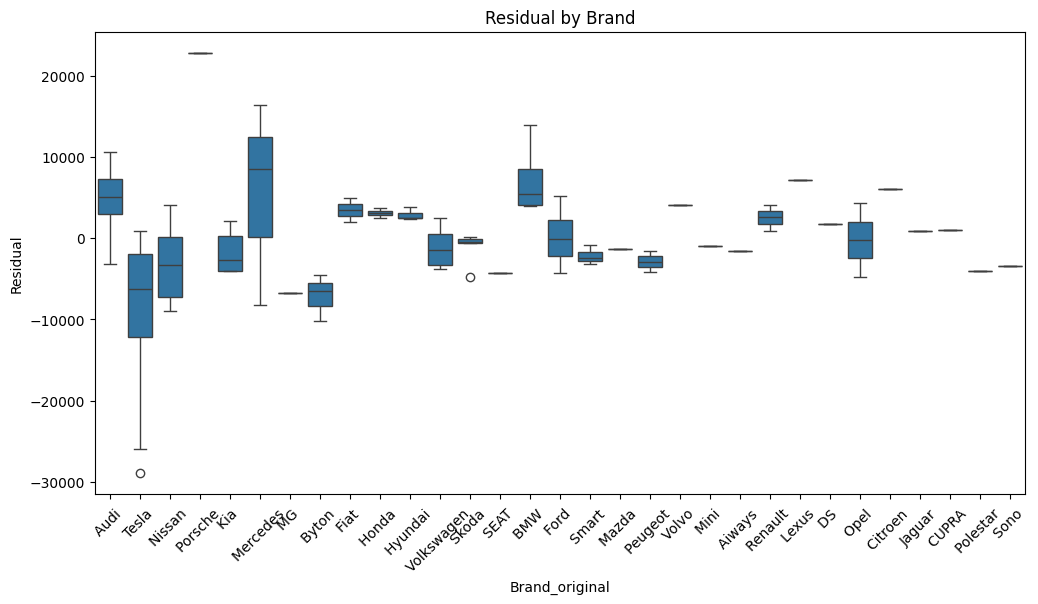

In [155]:
#結果の可視化①：Residual × ブランド　[ブランドごとのResidual]

plt.figure(figsize=(12,6))
sns.boxplot(x="Brand_original", y="Residual", data=df)

plt.xticks(rotation=45)
plt.title("Residual by Brand")
plt.show()

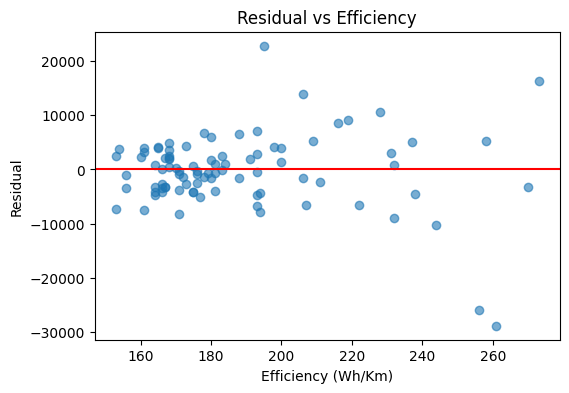

In [156]:
#結果の可視化②：Residual × Efficiency（電費効率）
#右（電費悪い）に行くほどResidual↑ → 割高傾向
#左（電費良い）でResidual↓ → コスパ良

plt.figure(figsize=(6,4))
plt.scatter(df["Efficiency_WhKm"], df["Residual"], alpha=0.6)

plt.axhline(0, color='red')

plt.xlabel("Efficiency (Wh/Km)")
plt.ylabel("Residual")
plt.title("Residual vs Efficiency")
plt.show()

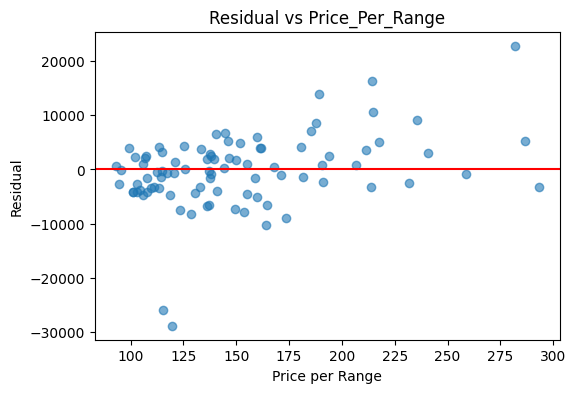

In [157]:
#結果の可視化③: Residual × Price_Per_Range（１Kmあたりのコスパ）
#高いほど（kmあたり高い） → 割高
#低いほど → 割安

plt.figure(figsize=(6,4))
plt.scatter(df["Price_Per_Range"], df["Residual"], alpha=0.6)

plt.axhline(0, color='red')

plt.xlabel("Price per Range")
plt.ylabel("Residual")
plt.title("Residual vs Price_Per_Range")
plt.show()

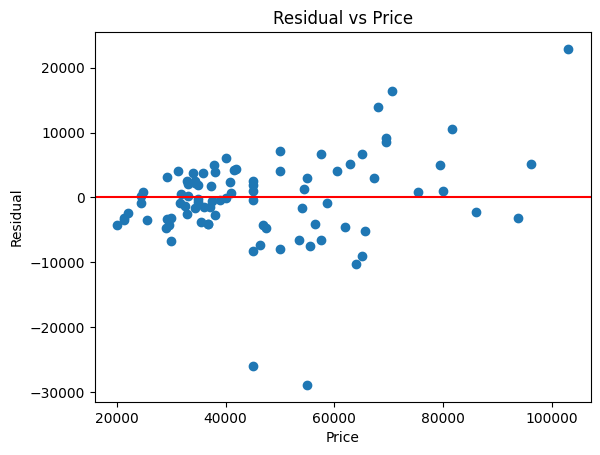

In [158]:


plt.scatter(df["PriceEuro"], df["Residual"])
plt.axhline(0, color='red')

plt.xlabel("Price")
plt.ylabel("Residual")
plt.title("Residual vs Price")
plt.show()

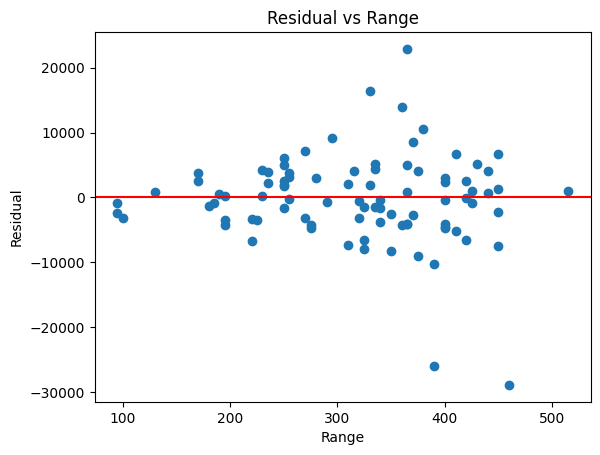

In [159]:
#結果の可視化④:Residual X Range　[Residualと走行距離]
#0より上（＋） → 割高
#0より下（−） → 割安

plt.scatter(df["Range_Km"], df["Residual"])
plt.axhline(0, color='red')

plt.xlabel("Range")
plt.ylabel("Residual")
plt.title("Residual vs Range")
plt.show()

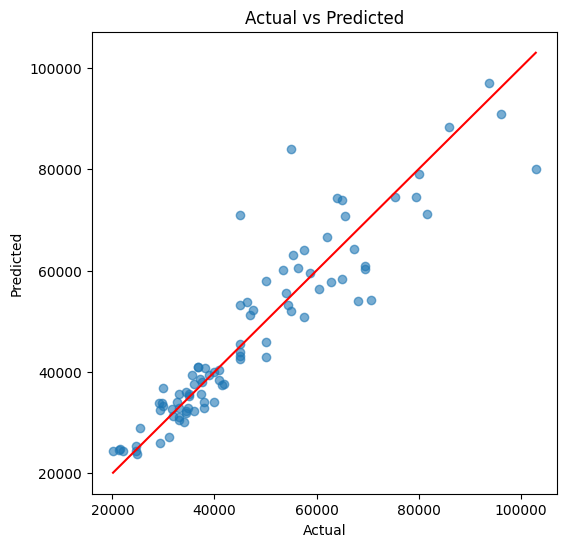

In [160]:
#結果の可視化⑤:Actual vs Predicted　[実際と予測]

plt.figure(figsize=(6,6))
plt.scatter(df["PriceEuro"], df["PredictedPrice"], alpha=0.6)

plt.plot(
    [df["PriceEuro"].min(), df["PriceEuro"].max()],
    [df["PriceEuro"].min(), df["PriceEuro"].max()],
    color='red'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()